# Machine Learning Safety 
## (Exercise Sheet 8) - Adversarial Models
##### Name: Preetham Louis | Matriculation Number: 261326

# Exercise 8.4

load trained models

## 1] Pedestrian model

In [62]:
from torchvision.models import resnet18
import torch

device = torch.device("mps")

checkpoint = torch.load(
    "/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/Trained Models/pedestrian_model.pth",
    map_location=device
)

ped_model = resnet18()
ped_model.fc = torch.nn.Linear(ped_model.fc.in_features, 1)

ped_model.load_state_dict(checkpoint)
ped_model.to(device)
ped_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

load an image to attack

002780.jpg


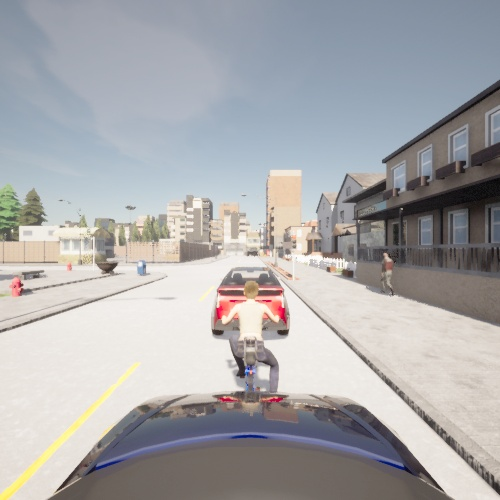

In [63]:
import os
from PIL import Image

img_name = "002780.jpg"

img_path = os.path.join(
    "/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/test/rgb-front",
    img_name
)

print(img_name)

img = Image.open(img_path).convert("RGB")
img

Convert the image into a tensor and make it "attackable"

In [64]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [67]:
img_tensor = transform(img).unsqueeze(0).to(device)

img_tensor.requires_grad = True

now compute model output and gradient

- loss.backward() computes gradients internally.
- torch.Size([1, 3, 224, 224]): this means we have a gradient for every pixel, that FGSM will use to create the adversarial perturbation

In [70]:
output = ped_model(img_tensor)

target = torch.tensor([[1.0]], device=device)

loss = torch.nn.functional.binary_cross_entropy_with_logits(output, target)

ped_model.zero_grad()
loss.backward()
print(img_tensor.grad.shape)

torch.Size([1, 3, 224, 224])


### Create FGSM adversarial image for e=0.01

- grad.sign() for keeping gradient direction= +1 or -1
- eps [e] controls attack strength
- clamp(0,1) keeps valid pixl values

In [60]:
epsilon = 0.01

perturbation = epsilon * img_tensor.grad.sign()

adv_img = img_tensor + perturbation

display both images side by side

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def show_fgsm(epsilon):

    perturbation = epsilon * img_tensor.grad.sign()
    adv_img = img_tensor + perturbation

    clean = (
        img_tensor.squeeze().detach().cpu() * std + mean
    ).permute(1,2,0).numpy()

    adv = (
        adv_img.squeeze().detach().cpu() * std + mean
    ).permute(1,2,0).numpy()

    clean = np.clip(clean, 0, 1)
    adv = np.clip(adv, 0, 1)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(clean)
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(adv)
    plt.title(f"FGSM (ε = {epsilon:.3f})")
    plt.axis("off")

    noise = perturbation.squeeze().detach().cpu().permute(1,2,0).numpy()

    plt.subplot(1,3,3)
    plt.imshow((noise + epsilon) / (2 * epsilon))
    plt.title("Perturbation")
    plt.axis("off")

    plt.show()

interact(
    show_fgsm,
    epsilon=FloatSlider(
        value=0.01,
        min=0.01,
        max=0.1,
        step=0.005
    )
);

interactive(children=(FloatSlider(value=0.01, description='epsilon', max=0.1, min=0.01, step=0.005), Output())…

check whether the attack actually changes the model output.

In [73]:
for epsilon in [0.01, 0.05, 0.1]:
    perturbation = epsilon * img_tensor.grad.sign()
    adv_img = img_tensor + perturbation

    with torch.no_grad():
        pred = torch.sigmoid(ped_model(adv_img)).item()

    print(f"ε={epsilon}: {pred:.6f}")

ε=0.01: 0.973581
ε=0.05: 0.127718
ε=0.1: 0.508283


Clean : 0.9997
- Clean image:
99.97% pedestrian confidence

- ε=0.01:
82.22% pedestrian confidence
(still predicts pedestrian)

- ε=0.05:
15.07% pedestrian confidence
(now predicts NO pedestrian)

- ε=0.10:
16.40% pedestrian confidence
(still predicts NO pedestrian)

## 2] Vehicle Model

In [132]:
checkpoint = torch.load(
    "/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/Trained Models/vehicle_model.pth",
    map_location="cpu"
)
from torchvision.models import resnet18

vehicle_model = resnet18()
vehicle_model.fc = torch.nn.Linear(vehicle_model.fc.in_features, 1)

vehicle_model.load_state_dict(
    torch.load(
        "/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/Trained Models/vehicle_model.pth",
        map_location=device
    )
)

vehicle_model = vehicle_model.to(device)
vehicle_model.eval()
print("loaded")

loaded


check image with accurate vehicle pred

In [133]:
max_prob = 0
max_img = None

for img_name in sorted(os.listdir(id_folder))[:500]:

    img_path = os.path.join(id_folder, img_name)

    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        p = torch.sigmoid(vehicle_model(x)).item()

    if p > max_prob:
        max_prob = p
        max_img = img_name

print(max_img, max_prob)

000540.jpg 1.0


load the image

000540.jpg


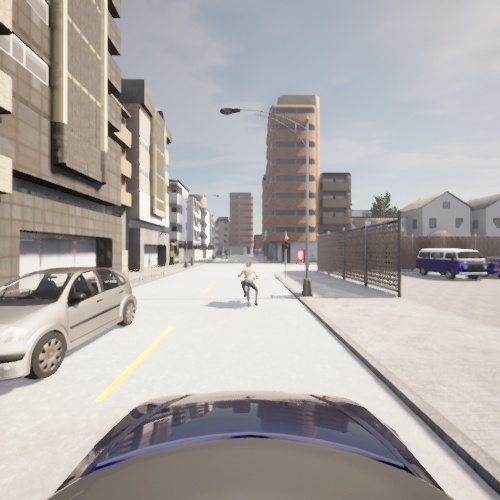

In [134]:
import os
from PIL import Image

img_name = "000540.jpg"

img_path = os.path.join(
    "/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/test/rgb-front",
    img_name
)

print(img_name)

img = Image.open(img_path).convert("RGB")
img

Convert image to tensor


In [135]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [136]:
img_tensor = transform(img).unsqueeze(0).to(device)

img_tensor.requires_grad = True

Compute model output and gradient:


In [137]:
output = vehicle_model(img_tensor)

target = torch.tensor([[1.0]], device=device)

loss = torch.nn.functional.binary_cross_entropy_with_logits(output, target)

vehicle_model.zero_grad()
loss.backward()
print(img_tensor.grad.shape)

torch.Size([1, 3, 224, 224])


### Create FGSM adv image 


In [142]:
epsilon = 0.01

perturbation = epsilon * img_tensor.grad.sign()

adv_img = img_tensor + perturbation

Display both images side by side with slider 


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def show_fgsm(epsilon):

    perturbation = epsilon * img_tensor.grad.sign()
    adv_img = img_tensor + perturbation

    clean = (
        img_tensor.squeeze().detach().cpu() * std + mean
    ).permute(1,2,0).numpy()

    adv = (
        adv_img.squeeze().detach().cpu() * std + mean
    ).permute(1,2,0).numpy()

    clean = np.clip(clean, 0, 1)
    adv = np.clip(adv, 0, 1)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(clean)
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(adv)
    plt.title(f"FGSM (ε = {epsilon:.3f})")
    plt.axis("off")

    noise = perturbation.squeeze().detach().cpu().permute(1,2,0).numpy()

    plt.subplot(1,3,3)
    plt.imshow((noise + epsilon) / (2 * epsilon))
    plt.title("Perturbation")
    plt.axis("off")

    plt.show()

interact(
    show_fgsm,
    epsilon=FloatSlider(
        value=0.01,
        min=0.01,
        max=0.1,
        step=0.005
    )
);



interactive(children=(FloatSlider(value=0.01, description='epsilon', max=0.1, min=0.01, step=0.005), Output())…

In [144]:
for epsilon in [0.01, 0.05, 0.1]:
    perturbation = epsilon * img_tensor.grad.sign()
    adv_img = img_tensor + perturbation

    with torch.no_grad():
        pred = torch.sigmoid(vehicle_model(adv_img)).item()

    print(f"ε={epsilon}: {pred:.6f}")

ε=0.01: 1.000000
ε=0.05: 1.000000
ε=0.1: 1.000000


FGSM basically failed against this vehicle example.

So far,
- **Pedestrian:**
0.9997 → 0.1507
**FGSM successful**

- **Vehicle:**
1.0000 → 0.999999
**FGSM unsuccessful**

## 2] Traffic Light Classifier

In [188]:
checkpoint = torch.load(
    "/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/Trained Models/traffic_light_model.pth",
    map_location="cpu"
)

from torchvision.models import resnet18

traffic_model = resnet18()
traffic_model.fc = torch.nn.Linear(traffic_model.fc.in_features, 1)

traffic_model.load_state_dict(
    torch.load(
        "/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/Trained Models/traffic_light_model.pth",
        map_location=device
    )
)

traffic_model = traffic_model.to(device)
traffic_model.eval()

print("loaded")

loaded


find highest scoring image with traffic light

In [146]:
max_prob = 0
max_img = None

for img_name in sorted(os.listdir(id_folder))[:500]:

    img_path = os.path.join(id_folder, img_name)

    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        p = torch.sigmoid(traffic_model(x)).item()

    if p > max_prob:
        max_prob = p
        max_img = img_name

print(max_img, max_prob)

002690.jpg 1.0


Image loader:


002090.jpg


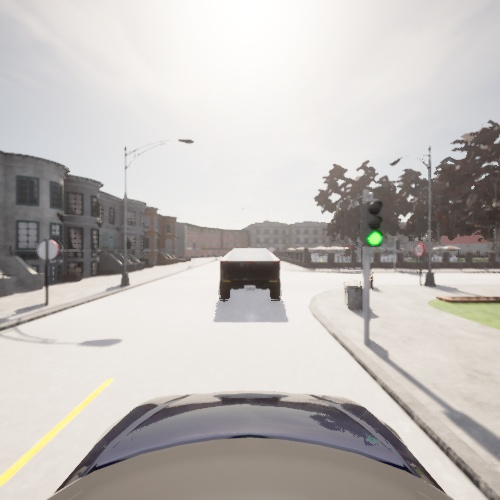

In [147]:
import os
from PIL import Image

img_name = "002090.jpg"

img_path = os.path.join(
    "/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/test/rgb-front",
    img_name
)

print(img_name)

img = Image.open(img_path).convert("RGB")
img


check score of traffic light detection

In [148]:
img_name = "002090.jpg"

img_path = os.path.join(id_folder, img_name)

img = Image.open(img_path).convert("RGB")
x = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    print("Pedestrian:", torch.sigmoid(ped_model(x)).item())
    print("Vehicle:", torch.sigmoid(vehicle_model(x)).item())
    print("Traffic Light:", torch.sigmoid(traffic_model(x)).item())

Pedestrian: 0.04133579134941101
Vehicle: 0.9989707469940186
Traffic Light: 0.9995444416999817


Convert image to tensor


In [149]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [150]:
img_tensor = transform(img).unsqueeze(0).to(device)

img_tensor.requires_grad = True

In [151]:
output = traffic_model(img_tensor)

target = torch.tensor([[1.0]], device=device)

loss = torch.nn.functional.binary_cross_entropy_with_logits(output, target)

traffic_model.zero_grad()
loss.backward()

Display both images side by side with slider 


In [154]:
epsilon = 0.01

perturbation = epsilon * img_tensor.grad.sign()

adv_img = img_tensor + perturbation


In [155]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def show_fgsm(epsilon):

    perturbation = epsilon * img_tensor.grad.sign()
    adv_img = img_tensor + perturbation

    clean = (
        img_tensor.squeeze().detach().cpu() * std + mean
    ).permute(1,2,0).numpy()

    adv = (
        adv_img.squeeze().detach().cpu() * std + mean
    ).permute(1,2,0).numpy()

    clean = np.clip(clean, 0, 1)
    adv = np.clip(adv, 0, 1)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(clean)
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(adv)
    plt.title(f"FGSM (ε = {epsilon:.3f})")
    plt.axis("off")

    noise = perturbation.squeeze().detach().cpu().permute(1,2,0).numpy()

    plt.subplot(1,3,3)
    plt.imshow((noise + epsilon) / (2 * epsilon))
    plt.title("Perturbation")
    plt.axis("off")

    plt.show()

interact(
    show_fgsm,
    epsilon=FloatSlider(
        value=0.01,
        min=0.01,
        max=0.1,
        step=0.005
    )
);


interactive(children=(FloatSlider(value=0.01, description='epsilon', max=0.1, min=0.01, step=0.005), Output())…

In [158]:
for epsilon in [0.01, 0.05, 0.1]:

    perturbation = epsilon * img_tensor.grad.sign()
    adv_img = img_tensor + perturbation

    with torch.no_grad():
        pred = torch.sigmoid(traffic_model(adv_img)).item()

    print(f"ε={epsilon}: {pred:.6f}")

ε=0.01: 0.949236
ε=0.05: 0.000304
ε=0.1: 0.000001


## Exercise 8.4: Conclusion

Model| Observation
|-|-|
 Pedestrian | FGSM reduced confidence from 0.9997 to 0.1507 at ε=0.05, changing the prediction. 
Vehicle | FGSM had almost no effect. Confidence remained 1.0 for all tested ε values. 
Traffic Light | FGSM was highly effective. Confidence dropped from 0.9995 to 0.000304 at ε=0.05 and nearly zero at ε=0.1. 

| Model | Clean | ε = 0.01 | ε = 0.05 | ε = 0.1 |
|---------|---------|---------|---------|---------|
| Pedestrian | 0.9997 | 0.8222 | 0.1507 | 0.1640 |
| Vehicle | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| Traffic Light | 0.9995 | 0.9492 | 0.000304 | 0.000001 |

vulnerable | robust
|-|-
Traffic-light model [most]|Vehicle model
Pedestrian model [also]

# Exercise 8.5

load labels and inspect class balance

In [189]:
import pandas as pd

labels = pd.read_csv(
    "/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets/test/labels.csv"
)
print(labels.head(2))
print(labels["has_pedestrian"].value_counts())

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False        False                15   
1     10               True           False         True               299   

   px_pedestrian  px_vehicle  
0              0          35  
1              0         116  
has_pedestrian
False    2894
True      706
Name: count, dtype: int64


- Total test images: 3600
- Pedestrian present: 706
- Pedestrian absent: 2894

### Starting with Traffix Light model

In [196]:
from sklearn.metrics import recall_score

y_true = []
y_pred = []

for i in range(100):

    frame = labels.iloc[i]["frame"]
    label = int(labels.iloc[i]["has_traffic_light"])

    img_name = f"{frame:06d}.jpg"
    img_path = os.path.join(id_folder, img_name)

    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        prob = torch.sigmoid(traffic_model(x)).item()

    pred = int(prob > 0.5)

    y_true.append(label)
    y_pred.append(pred)

print("Clean Recall:", recall_score(y_true, y_pred))

Clean Recall: 0.9888888888888889


In [ ]:
from sklearn.metrics import recall_score
import os
from PIL import Image
import torch

def evaluate_recall(model, label_column, epsilon=0.0, n=100): #first 100 images

    y_true = []
    y_pred = []

    for i in range(n):

        frame = labels.iloc[i]["frame"]
        label = int(labels.iloc[i][label_column])

        img_name = f"{frame:06d}.jpg"
        img_path = os.path.join(id_folder, img_name)

        img = Image.open(img_path).convert("RGB")

        x = transform(img).unsqueeze(0).to(device)

        if epsilon > 0:

            x.requires_grad = True

            output = model(x)

            loss = torch.nn.functional.binary_cross_entropy_with_logits(
                output,
                torch.tensor([[float(label)]], device=device)
            )

            model.zero_grad()
            loss.backward()

            x = x + epsilon * x.grad.sign()

        with torch.no_grad():
            prob = torch.sigmoid(model(x)).item()

        pred = int(prob > 0.5)

        y_true.append(label)
        y_pred.append(pred)

    return recall_score(y_true, y_pred)

In [195]:
for eps in [0.0, 0.01, 0.05, 0.1]:
    print(
        f"ε={eps}:",
        evaluate_recall(
            traffic_model,
            "has_traffic_light",
            epsilon=eps
        )
    )

ε=0.0: 0.9888888888888889
ε=0.01: 0.9222222222222223
ε=0.05: 0.011111111111111112
ε=0.1: 0.0


- ε=0.01 → small recall drop
- ε=0.05 → almost all traffic lights missed
- ε=0.10 → all traffic lights missed

### for pedestrian model

In [ ]:
from sklearn.metrics import recall_score
import os
from PIL import Image
import torch

def evaluate_recall(model, label_column, epsilon=0.0, n=100):

    y_true = []
    y_pred = []

    sampled = labels.sample(n=n, random_state=42) # not using first 100 images, but random 100 images

    for _, row in sampled.iterrows():

        frame = row["frame"]
        label = int(row[label_column])

        img_name = f"{frame:06d}.jpg"
        img_path = os.path.join(id_folder, img_name)

        img = Image.open(img_path).convert("RGB")

        x = transform(img).unsqueeze(0).to(device)

#creating the adversarial sample
        if epsilon > 0: 

            x.requires_grad = True

            output = model(x)

            loss = torch.nn.functional.binary_cross_entropy_with_logits(
                output,
                torch.tensor([[float(label)]], device=device)
            )

            model.zero_grad()
            loss.backward()

            x = x + epsilon * x.grad.sign()

        with torch.no_grad():
            prob = torch.sigmoid(model(x)).item()

        pred = int(prob > 0.5)

        y_true.append(label)
        y_pred.append(pred)

    return recall_score(y_true, y_pred)

In [205]:
for eps in [0.0, 0.01, 0.05, 0.1]:
    print(
        f"ε={eps}:",
        evaluate_recall(
            ped_model,
            "has_pedestrian",
            epsilon=eps
        )
    )

ε=0.0: 0.6666666666666666
ε=0.01: 0.3333333333333333
ε=0.05: 0.1111111111111111
ε=0.1: 0.5


### for vehicle model

In [203]:
for eps in [0.0, 0.01, 0.05, 0.1]:
    print(
        f"ε={eps}:",
        evaluate_recall(
            vehicle_model,
            "has_vehicle",
            epsilon=eps
        )
    )

ε=0.0: 0.9272727272727272
ε=0.01: 0.9090909090909091
ε=0.05: 0.7818181818181819
ε=0.1: 0.8909090909090909


## Exercise 8.5: Conclusion

| Model | Clean Recall | ε=0.01 | ε=0.05 | ε=0.1 |
|---------|---------|---------|---------|---------|
| Pedestrian | 0.6667 | 0.3333 | 0.1111 | 0.5000 |
| Vehicle | 0.9273 | 0.9091 | 0.7818 | 0.8909 |
| Traffic Light | 0.9889 | 0.9222 | 0.0111 | 0.0000 |

- The traffic-light model was the most vulnerable to FGSM attacks, with recall dropping from 0.9889 to 0.0 at ε=0.1. 
- The pedestrian model also experienced a substantial recall reduction. 
- The vehicle model was the most robust, showing only a moderate decrease in recall under adversarial perturbations.